In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "Data/spotify_global_trends.csv"
df = pd.read_csv(path)

print(df.head(5))


     track_name   artist_name   streams  stream_change      7day  \
0          SWIM           BTS  11273830       -3370522  25918182   
1  Body to Body           BTS   6815694       -4369341  18000729   
2      Babydoll  Dominic Fike   5733862         178968  36599831   
3      Hooligan           BTS   5338608       -3396855  14074071   
4           FYA           BTS   5196767       -2873904  13267438   

             genre  country  pos  days  viral_score    trend  \
0            K-Pop       KR    1     2     37192012  Falling   
1            K-Pop       KR    2     2     24816423  Falling   
2  Alternative Pop  Florida    3   119     42333693   Rising   
3            K-Pop       KR    4     2     19412679  Falling   
4            K-Pop       KR    5     2     18464205  Falling   

  popularity_category  longevity  
0            Trending        New  
1            Trending        New  
2            Trending  Evergreen  
3            Trending        New  
4            Trending        Ne

In [82]:
# USING STREAMS
print("Using Streams")

values = df['streams'].values
n = len(values)

# Mean manual
mean_manual = sum(values) / n

# Median manual
values_sorted = np.sort(values)
if n % 2 == 0:
    median_manual = (values_sorted[n//2 - 1] + values_sorted[n//2]) / 2
else:
    median_manual = values_sorted[n//2]

# Modus manual (nilai paling sering muncul)
unique, counts = np.unique(values, return_counts=True)
mode_manual = unique[counts.argmax()]

# Verifikasi dengan Pandas
mean_pd = df['streams'].mean()
median_pd = df['streams'].median()
mode_pd = df['streams'].mode()[0]

print('Manual Mean:', mean_manual)
print('Pandas Mean:', mean_pd)
print('Manual Median:', median_manual)
print('Pandas Median:', median_pd)
print('Manual Mode:', mode_manual)
print('Pandas Mode:', mode_pd)


Using Streams
Manual Mean: 2093366.3988764044
Pandas Mean: 2093366.3988764044
Manual Median: 1590738.0
Pandas Median: 1590738.0
Manual Mode: 1191777
Pandas Mode: 1191777


In [83]:
# USING VIRAL_SCORE
print("Using Viral_score")

values = df['viral_score'].values
n = len(values)

# Mean manual
mean_manual = sum(values) / n

# Median manual
values_sorted = np.sort(values)
if n % 2 == 0:
    median_manual = (values_sorted[n//2 - 1] + values_sorted[n//2]) / 2
else:
    median_manual = values_sorted[n//2]

# Modus manual (nilai paling sering muncul)
unique, counts = np.unique(values, return_counts=True)
mode_manual = unique[counts.argmax()]

# Verifikasi dengan Pandas
mean_pd = df['viral_score'].mean()
median_pd = df['viral_score'].median()
mode_pd = df['viral_score'].mode()[0]

print('Manual Mean:', mean_manual)
print('Pandas Mean:', mean_pd)
print('Manual Median:', median_manual)
print('Pandas Median:', median_pd)
print('Manual Mode:', mode_manual)
print('Pandas Mode:', mode_pd)


Using Viral_score
Manual Mean: 14534325.258426966
Pandas Mean: 14534325.258426966
Manual Median: 12570715.0
Pandas Median: 12570715.0
Manual Mode: 3774959
Pandas Mode: 3774959


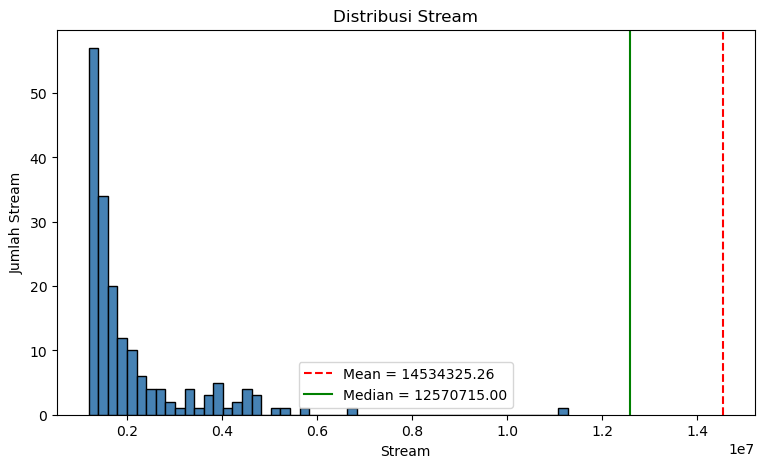

In [84]:
plt.figure(figsize=(9,5))
plt.hist(df['streams'], bins=50, color='steelblue', edgecolor='black')

plt.axvline(mean_pd, color='red', linestyle='--', label=f'Mean = {mean_pd:.2f}')
plt.axvline(median_pd, color='green', linestyle='-', label=f'Median = {median_pd:.2f}')

plt.title('Distribusi Stream')
plt.xlabel('Stream')
plt.ylabel('Jumlah Stream')
plt.legend()
plt.show()


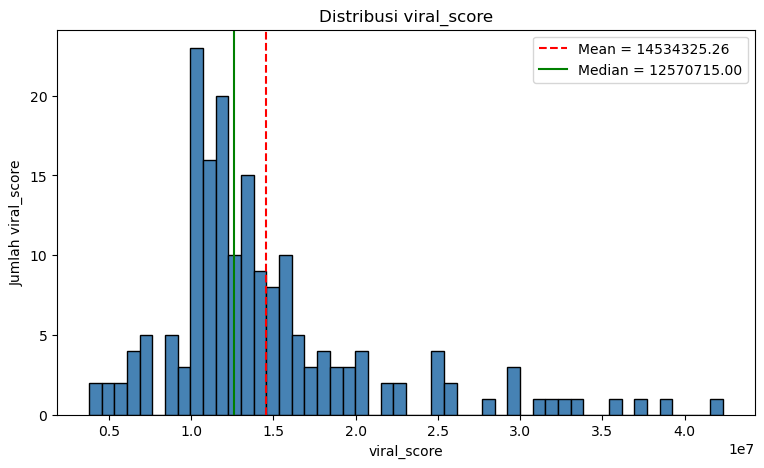

In [85]:
plt.figure(figsize=(9,5))
plt.hist(df['viral_score'], bins=50, color='steelblue', edgecolor='black')

plt.axvline(mean_pd, color='red', linestyle='--', label=f'Mean = {mean_pd:.2f}')
plt.axvline(median_pd, color='green', linestyle='-', label=f'Median = {median_pd:.2f}')

plt.title('Distribusi viral_score')
plt.xlabel('viral_score')
plt.ylabel('Jumlah viral_score')
plt.legend()
plt.show()

Std: 1277788.8718167164
Variance: 1632744400938.6367
Range: 10082053
IQR: 852534.75
P10, P25, P75, P90: 1262785.1 1350050.5 2202585.25 3907763.3000000003


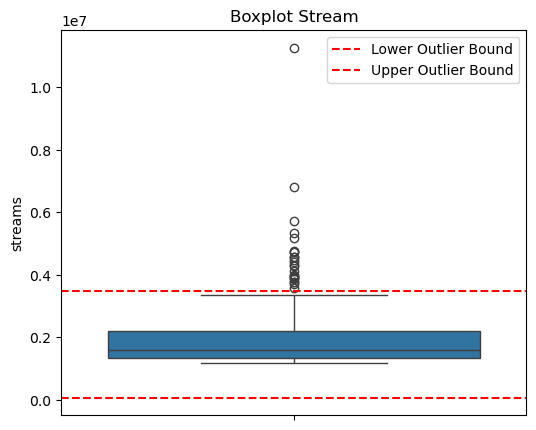

In [86]:
std_val = df['streams'].std()
var_val = df['streams'].var()
min_val = df['streams'].min()
max_val = df['streams'].max()
range_val = max_val - min_val

q1 = df['streams'].quantile(0.25)
q3 = df['streams'].quantile(0.75)
iqr = q3 - q1

p10 = df['streams'].quantile(0.10)
p25 = q1
p75 = q3
p90 = df['streams'].quantile(0.90)

print('Std:', std_val)
print('Variance:', var_val)
print('Range:', range_val)
print('IQR:', iqr)
print('P10, P25, P75, P90:', p10, p25, p75, p90)

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

plt.figure(figsize=(6,5))
sns.boxplot(y=df['streams'])
plt.axhline(lower_bound, color='red', linestyle='--', label='Lower Outlier Bound')
plt.axhline(upper_bound, color='red', linestyle='--', label='Upper Outlier Bound')
plt.title('Boxplot Stream')
plt.legend()
plt.show()


Std: 6699638.676995245
Variance: 44885158402290.59
Range: 38558734
IQR: 5406725.25
P10, P25, P75, P90: 8707626.3 10675436.0 16082161.25 23339514.700000025


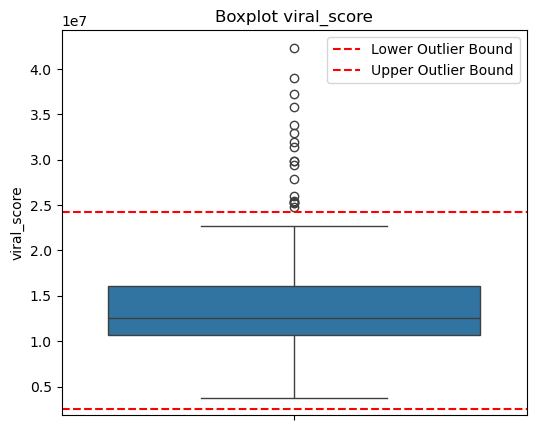

In [87]:
std_val = df['viral_score'].std()
var_val = df['viral_score'].var()
min_val = df['viral_score'].min()
max_val = df['viral_score'].max()
range_val = max_val - min_val

q1 = df['viral_score'].quantile(0.25)
q3 = df['viral_score'].quantile(0.75)
iqr = q3 - q1

p10 = df['viral_score'].quantile(0.10)
p25 = q1
p75 = q3
p90 = df['viral_score'].quantile(0.90)

print('Std:', std_val)
print('Variance:', var_val)
print('Range:', range_val)
print('IQR:', iqr)
print('P10, P25, P75, P90:', p10, p25, p75, p90)

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

plt.figure(figsize=(6,5))
sns.boxplot(y=df['viral_score'])
plt.axhline(lower_bound, color='red', linestyle='--', label='Lower Outlier Bound')
plt.axhline(upper_bound, color='red', linestyle='--', label='Upper Outlier Bound')
plt.title('Boxplot viral_score')
plt.legend()
plt.show()


In [88]:
outliers = df[(df['streams'] < lower_bound) | (df['streams'] > upper_bound)]
outlier_count = len(outliers)
outlier_pct = outlier_count / len(df) * 100

print('Jumlah Outlier:', outlier_count)
print('Persentase Outlier:', outlier_pct)


Jumlah Outlier: 143
Persentase Outlier: 80.33707865168539


In [89]:
outliers = df[(df['viral_score'] < lower_bound) | (df['viral_score'] > upper_bound)]
outlier_count = len(outliers)
outlier_pct = outlier_count / len(df) * 100

print('Jumlah Outlier:', outlier_count)
print('Persentase Outlier:', outlier_pct)


Jumlah Outlier: 18
Persentase Outlier: 10.112359550561797


In [90]:
df.head()

,track_name,artist_name,streams,stream_change,7day,genre,country,pos,days,viral_score,trend,popularity_category,longevity
0,SWIM,BTS,11273830,-3370522,25918182,K-Pop,KR,1,2,37192012,Falling,Trending,New
1,Body to Body,BTS,6815694,-4369341,18000729,K-Pop,KR,2,2,24816423,Falling,Trending,New
2,Babydoll,Dominic Fike,5733862,178968,36599831,Alternative Pop,Florida,3,119,42333693,Rising,Trending,Evergreen
3,Hooligan,BTS,5338608,-3396855,14074071,K-Pop,KR,4,2,19412679,Falling,Trending,New
4,FYA,BTS,5196767,-2873904,13267438,K-Pop,KR,5,2,18464205,Falling,Trending,New


In [91]:
group_stats = df.groupby('trend')['streams'].agg(['mean', 'median', 'std']).reset_index()
print(group_stats)


     trend          mean     median           std
0  Falling  2.150032e+06  1587695.0  1.371476e+06
1   Rising  1.904022e+06  1610233.0  8.842697e+05


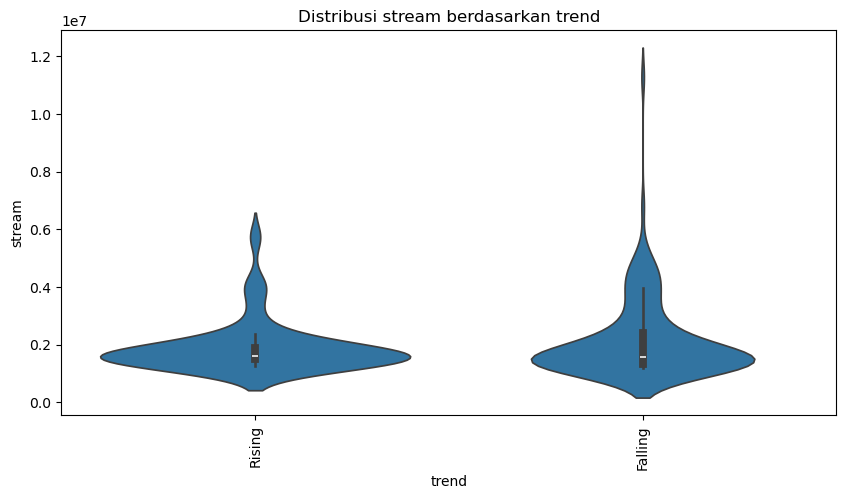

In [92]:
order = group_stats.sort_values('median', ascending=False)['trend']

plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='trend', y='streams', order=order)
plt.title('Distribusi stream berdasarkan trend')
plt.xticks(rotation=90)
plt.xlabel('trend')
plt.ylabel('stream')
plt.show()
